# 01. 데이터 로드 및 전처리

> 이 노트북은 원본 통합 노트북 `소스_코드_8팀_생체_신호_기반_흡연_여부_비교_시각화_프로젝트__-_종합.ipynb` 의 관련 셀들을 주제별로 재구성한 것입니다. 코드는 원본 그대로 옮겨왔으며(실행 결과만 초기화), 새로 작성하거나 수정한 로직은 없습니다.
>
> 실행하려면 `train_dataset.csv`(Kaggle: Smoker Status Prediction Dataset)를 동일 폴더에 두어야 합니다. 데이터 파일은 저장소에 포함되어 있지 않습니다.
>
> 원본에는 서로 다른 시점에 작성된 3개의 전처리 버전이 섞여 있습니다 (자세한 내용은 `docs/03_issues_and_troubleshooting.md` 참고). 이 재구성본은 그 버전들을 **삭제하거나 하나로 합치지 않고**, 각 노트북 안에서 '버전 A/B/C'로 구분해 모두 보존했습니다.

이 노트북은 원본에 섞여 있던 3개의 전처리 버전을 모두 담고 있습니다.

> ### ⚠️ 실행 순서 주의 — 파일 순서대로 돌리면 안 됩니다
>
> 이 노트북들은 원본 통합 노트북을 **주제별로** 재배치한 것이라,
> `01 → 02 → … → 06` 순서로 실행하면 변수 정의 순서가 깨집니다.
>
> 구체적으로 — `01` 의 **버전 B** 절이 `train = pd.read_csv(...)` 로 데이터를 다시 읽어
> **버전 A 에서 만든 `BMI_group` 컬럼을 지웁니다.** 그 상태로 `03` 을 실행하면
> `KeyError: 'BMI_group'` 이 납니다. (실제로 확인했습니다 — 파일 순서 실행 시 에러 47건)
>
> **이 노트북에 담긴 출력은 원본 통합 노트북의 셀 순서대로 실행해 얻은 것입니다.**
> 원본 코드셀 106개 중 105개가 매칭됐고, **실행 에러 0건 · 그래프 81개**가 재현됐습니다.
>
> 직접 재현하려면 `원본/소스_코드_8팀….ipynb` 를 순서대로 실행하거나,
> 각 절을 독립적으로 돌리려면 그 절 앞에서 데이터를 다시 읽고 파생 컬럼을 재생성해야 합니다.
>
> 데이터: `data/train_dataset.csv` (저장소 미포함 — [`data/README.md`](../../data/README.md))


## 버전 A — 초기 탐색 (이상치 기준: 시력 ≤ 3.0, BMI 5구간)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from math import pi

In [ ]:
# !pip install koreanize-matplotlib   # (로컬은 requirements.txt 로 설치)
import koreanize_matplotlib

In [ ]:
C_SMOKER = '#A63A50'
C_HIGH_BMI = '#C65D6E'
C_NONSMOKER = '#6B7075'
C_LOW_BMI = '#2F3437'
C_TEXT = '#1E1E1E'
C_GRID = '#D9D9D9'

sns.set_palette([C_NONSMOKER, C_SMOKER])
plt.rcParams.update({
    "text.color": C_TEXT,
    "axes.labelcolor": C_TEXT,
    "xtick.color": C_TEXT,
    "ytick.color": C_TEXT
})

In [ ]:
df = pd.read_csv('../../data/train_dataset.csv')

In [ ]:
df.head()

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
0,35,170,85,97.0,0.9,0.9,1,1,118,78,97,239,153,70,142,19.8,1,1.0,61,115,125,1,1
1,20,175,110,110.0,0.7,0.9,1,1,119,79,88,211,128,71,114,15.9,1,1.1,19,25,30,1,0
2,45,155,65,86.0,0.9,0.9,1,1,110,80,80,193,120,57,112,13.7,3,0.6,1090,1400,276,0,0
3,45,165,80,94.0,0.8,0.7,1,1,158,88,249,210,366,46,91,16.9,1,0.9,32,36,36,0,0
4,20,165,60,81.0,1.5,0.1,1,1,109,64,100,179,200,47,92,14.9,1,1.2,26,28,15,0,0


In [ ]:
df.info() # 결측치 없음

<class 'pandas.DataFrame'>
RangeIndex: 38984 entries, 0 to 38983
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  38984 non-null  int64  
 1   height(cm)           38984 non-null  int64  
 2   weight(kg)           38984 non-null  int64  
 3   waist(cm)            38984 non-null  float64
 4   eyesight(left)       38984 non-null  float64
 5   eyesight(right)      38984 non-null  float64
 6   hearing(left)        38984 non-null  int64  
 7   hearing(right)       38984 non-null  int64  
 8   systolic             38984 non-null  int64  
 9   relaxation           38984 non-null  int64  
 10  fasting blood sugar  38984 non-null  int64  
 11  Cholesterol          38984 non-null  int64  
 12  triglyceride         38984 non-null  int64  
 13  HDL                  38984 non-null  int64  
 14  LDL                  38984 non-null  int64  
 15  hemoglobin           38984 non-null  float64
 1

In [ ]:
df.duplicated().sum()
train = df.drop_duplicates()
train.duplicated().sum()

np.int64(0)

In [ ]:
train.describe() #시력 9.9, ALT 2914등 이상치 값이 많다는 사실을 알 수 있다.

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
count,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000,33467.000000
mean,44.153943,164.684465,65.930319,82.081501,1.013849,1.009553,1.025368,1.026056,121.498730,76.017599,99.261511,196.964562,126.806048,57.257537,115.182090,14.624463,1.086533,0.886467,26.195536,27.139929,39.952401,0.214689,0.366271
std,12.071768,9.195867,12.877955,9.310533,0.496245,0.497867,0.157243,0.159303,13.671019,9.672070,20.484366,36.416775,71.765510,14.598021,43.159159,1.562414,0.403008,0.222038,18.760580,31.613159,49.965736,0.410613,0.481792
min,20.000000,130.000000,30.000000,51.000000,0.100000,0.100000,1.000000,1.000000,71.000000,40.000000,46.000000,55.000000,8.000000,4.000000,1.000000,4.900000,1.000000,0.100000,6.000000,1.000000,2.000000,0.000000,0.000000
25%,40.000000,160.000000,55.000000,76.000000,0.800000,0.800000,1.000000,1.000000,112.000000,70.000000,89.000000,172.000000,75.000000,47.000000,92.000000,13.600000,1.000000,0.800000,19.000000,15.000000,17.000000,0.000000,0.000000
50%,40.000000,165.000000,65.000000,82.000000,1.000000,1.000000,1.000000,1.000000,120.000000,76.000000,96.000000,195.000000,108.000000,55.000000,113.000000,14.800000,1.000000,0.900000,23.000000,21.000000,26.000000,0.000000,0.000000
75%,55.000000,170.000000,75.000000,88.000000,1.200000,1.200000,1.000000,1.000000,130.000000,82.000000,104.000000,220.000000,160.000000,66.000000,136.000000,15.700000,1.000000,1.000000,29.000000,31.000000,44.000000,0.000000,1.000000
max,85.000000,190.000000,135.000000,129.000000,9.900000,9.900000,2.000000,2.000000,233.000000,146.000000,423.000000,445.000000,999.000000,359.000000,1860.000000,21.100000,6.000000,11.600000,1090.000000,2914.000000,999.000000,1.000000,1.000000


In [ ]:
train = df[
    (df['Gtp'] < 500) &
    (df['ALT'] < 500) &
    (df['AST'] < 500) &
    (df['LDL'] < 400) &
    (df['serum creatinine'] < 3.0) &
    (df['eyesight(left)'] <= 3.0) &
    (df['eyesight(right)'] <= 3.0)
].copy()
train.describe()
# 이상치 제거 완료

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
count,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000
mean,44.077568,164.695534,65.941533,82.047630,0.999411,0.993645,1.025013,1.025761,121.442204,75.980305,99.282550,196.939313,126.645147,57.292488,114.556427,14.623696,1.085003,0.884228,25.877956,26.692669,38.710712,0.214584,0.366882
std,12.041763,9.191880,12.895172,9.325185,0.326393,0.325241,0.156166,0.158425,13.632417,9.658122,20.522204,36.327260,71.733931,14.616465,33.557568,1.566662,0.396592,0.191950,13.597727,20.422636,41.335390,0.410539,0.481960
min,20.000000,130.000000,30.000000,51.000000,0.100000,0.100000,1.000000,1.000000,71.000000,40.000000,46.000000,55.000000,8.000000,4.000000,1.000000,4.900000,1.000000,0.100000,6.000000,1.000000,3.000000,0.000000,0.000000
25%,40.000000,160.000000,55.000000,76.000000,0.800000,0.800000,1.000000,1.000000,112.000000,70.000000,89.000000,172.000000,74.000000,47.000000,92.000000,13.600000,1.000000,0.800000,19.000000,15.000000,17.000000,0.000000,0.000000
50%,40.000000,165.000000,65.000000,82.000000,1.000000,1.000000,1.000000,1.000000,120.000000,76.000000,96.000000,195.000000,108.000000,55.000000,113.000000,14.800000,1.000000,0.900000,23.000000,21.000000,26.000000,0.000000,0.000000
75%,55.000000,170.000000,75.000000,88.000000,1.200000,1.200000,1.000000,1.000000,130.000000,82.000000,104.000000,219.000000,160.000000,66.000000,136.000000,15.800000,1.000000,1.000000,28.000000,31.000000,43.000000,0.000000,1.000000
max,85.000000,190.000000,135.000000,129.000000,2.000000,2.000000,2.000000,2.000000,233.000000,146.000000,423.000000,445.000000,999.000000,359.000000,379.000000,21.100000,6.000000,2.600000,387.000000,471.000000,497.000000,1.000000,1.000000


In [ ]:
train['BMI'] = train['weight(kg)']/(train['height(cm)']/100)**2
train['BMI_group'] =pd.cut(train['BMI'],
                                 bins=[0, 18.5, 23, 25, 30, 100],
                                 labels=['저체중', '정상', '과체중', '비만2단계', '고도비만'])
train['BMI_group']
#BMI 분류하기

0        비만2단계
1         고도비만
3        비만2단계
4           정상
5           정상
         ...  
38979       정상
38980       정상
38981     고도비만
38982       정상
38983       정상
Name: BMI_group, Length: 38740, dtype: category
Categories (5, str): ['저체중' < '정상' < '과체중' < '비만2단계' < '고도비만']

## 버전 B — 나눔 폰트 설치 및 회귀분석용 정리본 (high_BMI 이진변수, 연령대 6구간)

In [ ]:
!apt-get update -qq
!apt-get install -y fonts-nanum -qq

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

nanum_fonts = sorted(set(
    f.name for f in fm.fontManager.ttflist
    if 'Nanum' in f.name
))
print(nanum_fonts)

['NanumGothic', 'NanumGothic Light', 'NanumGothicExtraBold']


In [ ]:
!ls /usr/share/fonts/truetype/nanum

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = 'C:/Windows/Fonts/malgun.ttf'
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

print("사용 폰트:", font_name)

사용 폰트: Malgun Gothic


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import mannwhitneyu
import statsmodels.formula.api as smf

COLOR_SMOKER = '#A63A50'
COLOR_HIGH_BMI = '#C65D6E'
COLOR_NONSMOKER = '#6B7075'
COLOR_LOW_BMI = '#2F3437'
COLOR_TEXT = '#1E1E1E'
COLOR_GRID = '#D9D9D9'

plt.rcParams['axes.unicode_minus'] = False


train = pd.read_csv('../../data/train_dataset.csv')


train_clean = train[
    (train['Gtp'] < 500) &
    (train['ALT'] < 500) &
    (train['AST'] < 500) &
    (train['LDL'] < 400) &
    (train['serum creatinine'] < 3.0) &
    (train['eyesight(left)'] <= 3.0) &
    (train['eyesight(right)'] <= 3.0)
].copy()

# BMI 생성
train_clean['BMI'] = train_clean['weight(kg)'] / ((train_clean['height(cm)'] / 100) ** 2)

# 고BMI 변수 생성
train_clean['high_BMI'] = (train_clean['BMI'] >= 25).astype(int)

# 연령대 변수 생성
train_clean['age_group'] = pd.cut(
    train_clean['age'],
    bins=[15, 29, 39, 49, 59, 69, 120],
    labels=['20대', '30대', '40대', '50대', '60대', '70대+']
)

print("원본 데이터 크기:", train.shape)
print("전처리 후 데이터 크기:", train_clean.shape)
display(train_clean.head())
display(train_clean.describe())

원본 데이터 크기: (38984, 23)
전처리 후 데이터 크기: (38740, 26)
   age  height(cm)  weight(kg)  ...        BMI  high_BMI  age_group
0   35         170          85  ...  29.411765         1        30대
1   20         175         110  ...  35.918367         1        20대
3   45         165          80  ...  29.384757         1        40대
4   20         165          60  ...  22.038567         0        20대
5   60         160          50  ...  19.531250         0        60대

[5 rows x 26 columns]
                age    height(cm)  ...           BMI      high_BMI
count  38740.000000  38740.000000  ...  38740.000000  38740.000000
mean      44.077568    164.695534  ...     24.179562      0.357073
std       12.041763      9.191880  ...      3.502443      0.479143
min       20.000000    130.000000  ...     14.268728      0.000000
25%       40.000000    160.000000  ...     21.604938      0.000000
50%       40.000000    165.000000  ...     23.875115      0.000000
75%       55.000000    170.000000  ...     26.12244

## 버전 C — 발표 반영본 (이상치 기준: 시력 ≤ 2.0, BMI 6구간, WHtR 추가)

In [ ]:
!sudo apt-get install -y fonts-nanum                  # 나눔 폰트 설치
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math as ma

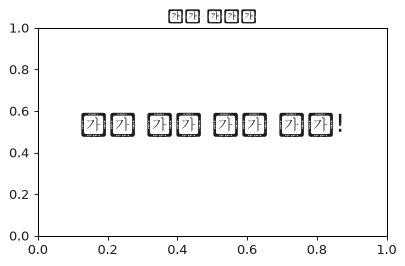

In [ ]:
import matplotlib.pyplot as plt

plt.rc('font', family='NanumBarunGothic')           # 한글 폰트 설정 테스트
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(5, 3))                          # 설치 확인
plt.text(0.5, 0.5, '한글 폰트 설치 성공!', size=20, ha='center')
plt.title('폰트 테스트')
plt.show()

In [ ]:
# 1) CSV 파일을 읽어 DataFrame 생성
manu_path = '../../data/train_dataset.csv'        # train_dataset.csv 파일 경로 입력

df = pd.read_csv(manu_path)


df.head(5)                                      # df의x 상위 5개 행을 확인하고 출력

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
0,35,170,85,97.0,0.9,0.9,1,1,118,78,97,239,153,70,142,19.8,1,1.0,61,115,125,1,1
1,20,175,110,110.0,0.7,0.9,1,1,119,79,88,211,128,71,114,15.9,1,1.1,19,25,30,1,0
2,45,155,65,86.0,0.9,0.9,1,1,110,80,80,193,120,57,112,13.7,3,0.6,1090,1400,276,0,0
3,45,165,80,94.0,0.8,0.7,1,1,158,88,249,210,366,46,91,16.9,1,0.9,32,36,36,0,0
4,20,165,60,81.0,1.5,0.1,1,1,109,64,100,179,200,47,92,14.9,1,1.2,26,28,15,0,0


In [ ]:
df['BMI'] = df['weight(kg)'] / ((df['height(cm)'] / 100) ** 2)        # BMI 추가
df['WHtR'] = df['waist(cm)'] / df['height(cm)']                       # WHtR 추가

display(df[['height(cm)', 'weight(kg)', 'waist(cm)', 'BMI', 'WHtR']].head())

   height(cm)  weight(kg)  waist(cm)        BMI      WHtR
0         170          85       97.0  29.411765  0.570588
1         175         110      110.0  35.918367  0.628571
2         155          65       86.0  27.055151  0.554839
3         165          80       94.0  29.384757  0.569697
4         165          60       81.0  22.038567  0.490909


In [ ]:
# 필터적용
train_clean = df[
    (df['Gtp'] < 500) &
    (df['ALT'] < 500) &
    (df['AST'] < 500) &
    (df['LDL'] < 400) &
    (df['serum creatinine'] < 3.0) &
    (df['eyesight(left)'] <= 2.0) &
    (df['eyesight(right)'] <= 2.0)
].copy()
train_clean.describe()

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking,BMI,WHtR
count,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000,38740.000000
mean,44.077568,164.695534,65.941533,82.047630,0.999411,0.993645,1.025013,1.025761,121.442204,75.980305,99.282550,196.939313,126.645147,57.292488,114.556427,14.623696,1.085003,0.884228,25.877956,26.692669,38.710712,0.214584,0.366882,24.179562,0.498551
std,12.041763,9.191880,12.895172,9.325185,0.326393,0.325241,0.156166,0.158425,13.632417,9.658122,20.522204,36.327260,71.733931,14.616465,33.557568,1.566662,0.396592,0.191950,13.597727,20.422636,41.335390,0.410539,0.481960,3.502443,0.053220
min,20.000000,130.000000,30.000000,51.000000,0.100000,0.100000,1.000000,1.000000,71.000000,40.000000,46.000000,55.000000,8.000000,4.000000,1.000000,4.900000,1.000000,0.100000,6.000000,1.000000,3.000000,0.000000,0.000000,14.268728,0.318750
25%,40.000000,160.000000,55.000000,76.000000,0.800000,0.800000,1.000000,1.000000,112.000000,70.000000,89.000000,172.000000,74.000000,47.000000,92.000000,13.600000,1.000000,0.800000,19.000000,15.000000,17.000000,0.000000,0.000000,21.604938,0.462353
50%,40.000000,165.000000,65.000000,82.000000,1.000000,1.000000,1.000000,1.000000,120.000000,76.000000,96.000000,195.000000,108.000000,55.000000,113.000000,14.800000,1.000000,0.900000,23.000000,21.000000,26.000000,0.000000,0.000000,23.875115,0.495381
75%,55.000000,170.000000,75.000000,88.000000,1.200000,1.200000,1.000000,1.000000,130.000000,82.000000,104.000000,219.000000,160.000000,66.000000,136.000000,15.800000,1.000000,1.000000,28.000000,31.000000,43.000000,0.000000,1.000000,26.122449,0.531429
max,85.000000,190.000000,135.000000,129.000000,2.000000,2.000000,2.000000,2.000000,233.000000,146.000000,423.000000,445.000000,999.000000,359.000000,379.000000,21.100000,6.000000,2.600000,387.000000,471.000000,497.000000,1.000000,1.000000,42.448980,0.798125


In [ ]:
# 나이를 20-35를 '청년', 36-50을 '중년', 51-64 를 '장년', 65 이상 '노년'으로 해서 나이를 4 그룹으로 분류한 값 추가
bins = [0, 35, 50, 64, 150]
labels = ['청년', '중년', '장년', '노년']

train_clean['age_group'] = pd.cut(train_clean['age'], bins=bins, labels=labels, right=True)

display(train_clean[['age', 'age_group']].head())

   age age_group
0   35        청년
1   20        청년
3   45        중년
4   20        청년
5   60        장년


In [ ]:
# BMI 분류 및 항목 추가
bmi_bins = [0, 18.5, 23, 25, 30, 35, 100]
bmi_labels = ['저체중', '정상', '과체중', '1단계 비만', '2단계 비만', '3단계 비만']

train_clean['bmi_group'] = pd.cut(train_clean['BMI'], bins=bmi_bins, labels=bmi_labels, right=False)

display(train_clean[['BMI', 'bmi_group']].head())

         BMI bmi_group
0  29.411765    1단계 비만
1  35.918367    3단계 비만
3  29.384757    1단계 비만
4  22.038567        정상
5  19.531250        정상
